<a href="https://colab.research.google.com/github/Mariagiusi23/ID-001-AWOL-for-Audio/blob/main/notebook/02_Enhanced_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Notebook 2 — Enhanced baseline (MLP + CLAP auxiliary loss)

In Notebook 1, I built a simple baseline that mapped CLAP embeddings to FM synthesizer parameters using a plain MLP.  
Here, I improve that baseline by introducing two modifications:  
1. **Weighted parameter loss**, to stabilize harder dimensions (e.g., the ratio).  
2. **CLAP-based auxiliary loss**, which encourages semantic alignment between text prompts and the generated audio.  

My goal is to test whether these improvements lead to lower RMSE on the synthesizer parameters and higher CLAP cosine similarity compared to the baseline.




#**🎯 STEP 1 — Setup**

**📍 1.1 — Imports & environment**

In [1]:
import os, math, json, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torchaudio
from torchaudio.functional import resample
from transformers import AutoProcessor, ClapModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

**📍 1.2 — Reproducibility & device**

In [2]:
SEED = 123
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


**📍 1.3 — Global constants & I/O**

In [3]:
SR = 16000
DURATION = 1.5
N_SAMPLES = int(SR * DURATION)

OUTDIR = Path("outputs_nb02")
AUDIO_DIR = OUTDIR / "audio"
CKPT_DIR  = OUTDIR / "ckpt"
for d in [OUTDIR, AUDIO_DIR, CKPT_DIR]: d.mkdir(parents=True, exist_ok=True)

CLAP_ID = "laion/clap-htsat-fused"

#**🎯 STEP 2 — Data**

**📍2.1 — Prompts & normalized parameters in [0,1]**

In [4]:
dataset = [
    {"prompt": "a high whistle",               "params": [0.60, 0.90, 0.10, 0.30]},
    {"prompt": "a deep rumbling drone",        "params": [0.50, 0.05, 0.20, 0.70]},
    {"prompt": "a bright metallic ping",       "params": [0.70, 0.70, 0.80, 0.40]},
    {"prompt": "a mellow flute tone",          "params": [0.40, 0.40, 0.25, 0.20]},
    {"prompt": "an aggressive buzzy lead",     "params": [0.85, 0.65, 0.90, 0.90]},
    {"prompt": "a soft sine beep",             "params": [0.30, 0.30, 0.10, 0.05]},
    {"prompt": "a glassy bell",                "params": [0.55, 0.80, 0.60, 0.50]},
    {"prompt": "a warm pad",                   "params": [0.45, 0.35, 0.35, 0.25]},
    {"prompt": "a harsh resonant tone",        "params": [0.80, 0.50, 0.95, 0.75]},
    {"prompt": "a soft low hum",               "params": [0.25, 0.15, 0.20, 0.10]},
]
prompts = [d["prompt"] for d in dataset]
Y = np.array([d["params"] for d in dataset], dtype=np.float32)
len(prompts), Y.shape

(10, (10, 4))

#**🎯 STEP 3 — CLAP embeddings**

**📍3.1 — Load CLAP**

In [28]:
processor = AutoProcessor.from_pretrained(CLAP_ID)
clap = ClapModel.from_pretrained(CLAP_ID).to(DEVICE).eval()

**📍3.2 — Text → emb**

In [6]:
@torch.no_grad()
def text_to_emb(texts):
    inp = processor(text=texts, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
    out = clap.get_text_features(**inp)
    return torch.nn.functional.normalize(out, dim=-1)

with torch.no_grad():
    X_text = text_to_emb(prompts).cpu().numpy()
X_text.shape

(10, 512)

#**🎯 STEP 4 — FM Synthesis (deterministic DSP)**

**📍4.1 — Denorm**

In [7]:
def denorm_params(params):
    A  = params[..., 0]
    fc = 100.0 + params[..., 1] * 3900.0
    r  = 0.25  + params[..., 2] * 7.75
    I  = 0.0   + params[..., 3] * 10.0
    return A, fc, r, I

**📍4.2 — FM synth**

In [8]:
def synth_fm(params, sr=SR, duration=DURATION):
    A, fc, r, I = denorm_params(torch.tensor(params, dtype=torch.float32))
    n = int(sr*duration)
    t = torch.arange(n, dtype=torch.float32)/sr
    fm = fc * r
    carr = 2*math.pi*fc*t
    mod  = torch.sin(2*math.pi*fm*t)
    y = A * torch.sin(carr + I*mod)
    fade = torch.linspace(0, 1, int(0.01*sr)); env = torch.ones_like(y)
    env[:len(fade)] *= fade; env[-len(fade):] *= torch.flip(fade, dims=[0])
    return (y*env).clamp(-1,1)

**📍4.3 — Audio emb + metrics**

In [9]:
@torch.no_grad()
def audio_to_emb(wav_tensor, sr=SR):
    if sr != 48000:
        wav_res = resample(wav_tensor.unsqueeze(0), sr, 48000).squeeze(0)
        sr_use = 48000
    else:
        wav_res = wav_tensor; sr_use = sr
    inp = processor(audios=wav_res.unsqueeze(0).cpu().numpy(), sampling_rate=sr_use, return_tensors="pt")
    inp = {k: v.to(DEVICE) for k,v in inp.items()}
    feats = clap.get_audio_features(**inp)
    return torch.nn.functional.normalize(feats, dim=-1).squeeze(0)

def cosine_sim(a, b):
    a = a/(a.norm()+1e-8); b = b/(b.norm()+1e-8)
    return torch.dot(a,b).item()

def param_rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred)**2)))

def rmse_per_dim(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2, axis=0))

#**🎯 STEP 5 — Split**

In [10]:
X = X_text; y = Y
X_tr, X_va, y_tr, y_va, idx_tr, idx_va = train_test_split(
    X, y, np.arange(len(X)), test_size=0.2, random_state=SEED
)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(DEVICE)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(DEVICE)
X_va_t = torch.tensor(X_va, dtype=torch.float32).to(DEVICE)
y_va_t = torch.tensor(y_va, dtype=torch.float32).to(DEVICE)

train_prompts = [prompts[i] for i in idx_tr]
val_prompts   = [prompts[i] for i in idx_va]

D = X.shape[1]
print("Embed dim:", D, "| Train:", len(X_tr), "| Val:", len(X_va))

Embed dim: 512 | Train: 8 | Val: 2


#**🎯 STEP 6 — Model: MLPPro**

**📍6.1 — MLPPro**

In [11]:
class MLPPro(nn.Module):
    def __init__(self, d_in, d_out=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 512), nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, d_out),
        )
    def forward(self, x):
        return torch.sigmoid(self.net(x))  # outputs in [0,1]

**📍6.2 — Training**

In [12]:
def train_model_pro(model, X_tr, y_tr, X_va, y_va,
                    lr=2e-3, steps=2500, wd=1e-4,
                    w_params=(1.0, 1.0, 1.6, 1.0),
                    use_clap_aux=True, clap_alpha=0.05, aux_every=100,
                    train_prompts=None):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    mse = nn.MSELoss(reduction='none')
    W = torch.tensor(w_params, device=DEVICE)

    best = {"val": 1e9, "state": None}
    for step in range(1, steps+1):
        model.train(); opt.zero_grad()
        y_pred = model(X_tr)
        loss_params = (mse(y_pred, y_tr) * W).mean()

        loss = loss_params
        if use_clap_aux and (step % aux_every == 0) and (train_prompts is not None):

            with torch.no_grad():
                y_pred_np = y_pred.detach().cpu().numpy()
            aux_vals = []

            for i in range(y_pred_np.shape[0]):
                audio = synth_fm(y_pred_np[i])
                a_emb = audio_to_emb(audio)
                t_emb = text_to_emb([train_prompts[i]]).squeeze(0)
                aux_vals.append(1.0 - torch.dot(
                    a_emb/(a_emb.norm()+1e-8), t_emb/(t_emb.norm()+1e-8)
                ).clamp(-1,1))
            loss_aux = torch.stack(aux_vals).mean()
            loss = loss + clap_alpha * loss_aux

        loss.backward(); opt.step()

        # validation
        if step % 50 == 0 or step == steps:
            model.eval()
            with torch.no_grad():
                val = (mse(model(X_va), y_va) * W).mean().item()
            if val < best["val"]:
                best["val"] = val
                best["state"] = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    return model, best["val"]


**📍6.3 — Train run**

In [13]:
mlp_pro = MLPPro(D)
mlp_pro, val_mse = train_model_pro(
    mlp_pro, X_tr_t, y_tr_t, X_va_t, y_va_t,
    lr=2e-3, steps=2500, wd=1e-4,
    w_params=(1.0, 1.0, 1.6, 1.0),
    use_clap_aux=True, clap_alpha=0.05, aux_every=100,
    train_prompts=train_prompts
)
torch.save(mlp_pro.state_dict(), CKPT_DIR / "mlp_pro.pt")
print("Best Val MSE (weighted):", val_mse)

Best Val MSE (weighted): 0.0988999754190445


#**🎯 STEP 7 — Evaluation**

**📍7.1 — Predict helper**

In [14]:
def predict_params(model, X_np):
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
        y_hat = model(X_t).cpu().numpy()
    return y_hat

**📍7.2 — RMSE**

In [15]:
y_hat = predict_params(mlp_pro, X)
rmse_global = param_rmse(Y, y_hat)
rmse_dims = rmse_per_dim(Y, y_hat)
print("Param RMSE (global):", round(rmse_global, 4))
print("Param RMSE per-dim [amp, f_c_norm, r_norm, I_norm]:", np.round(rmse_dims, 4))

Param RMSE (global): 0.1265
Param RMSE per-dim [amp, f_c_norm, r_norm, I_norm]: [0.0805 0.1525 0.1594 0.0941]


**📍7.3 — CLAP cosine + WAV**

In [16]:
@torch.no_grad()
def eval_clap_cosines(model, prompts, X_text_np, save_prefix):
    cosines = []
    for i, prompt in enumerate(prompts):
        x = torch.tensor(X_text_np[i:i+1], dtype=torch.float32, device=DEVICE)
        y_pred = model(x).squeeze(0).detach().cpu().numpy()
        y_audio = synth_fm(y_pred)
        out_path = AUDIO_DIR / f"{save_prefix}_{i:02d}.wav"
        torchaudio.save(str(out_path), y_audio.unsqueeze(0), SR)
        a_emb = audio_to_emb(y_audio)
        t_emb = text_to_emb([prompt]).squeeze(0)
        cosines.append(cosine_sim(a_emb, t_emb))
    return cosines

cos_mlpPro = eval_clap_cosines(mlp_pro, prompts, X_text, "mlpPro")
print("CLAP cosine — MLPPro:", np.round(cos_mlpPro, 3))
print("Avg cosine — MLPPro:", float(np.mean(cos_mlpPro)))


/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:247: UserWarning: torio.io._streaming_media_encoder.StreamingMediaEncoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  s 

CLAP cosine — MLPPro: [-0.019 -0.076  0.055 -0.069  0.069  0.146 -0.143  0.016  0.214 -0.016]
Avg cosine — MLPPro: 0.01766422651708126


#**🎯 STEP 8 — Log & export**

**📍8.1 — Save metrics**

In [17]:
metrics = {
    "val_mse_weighted": float(val_mse),
    "rmse_params_global": float(rmse_global),
    "rmse_params_per_dim": [float(x) for x in rmse_dims],
    "clap_cosine": [float(x) for x in cos_mlpPro],
    "clap_cosine_avg": float(np.mean(cos_mlpPro)),
    "sr": SR, "duration": DURATION, "model": CLAP_ID,
    "w_params": [1.0, 1.0, 1.6, 1.0],
    "use_clap_aux": True, "clap_alpha": 0.05, "aux_every": 100,
}
with open(OUTDIR / "metrics_nb02.json", "w") as f:
    json.dump(metrics, f, indent=2)
metrics

{'val_mse_weighted': 0.0988999754190445,
 'rmse_params_global': 0.12648743391036987,
 'rmse_params_per_dim': [0.08048046380281448,
  0.15246513485908508,
  0.15944169461727142,
  0.09408456832170486],
 'clap_cosine': [-0.019168272614479065,
  -0.076398104429245,
  0.05535564571619034,
  -0.06857113540172577,
  0.06876375526189804,
  0.14562204480171204,
  -0.142915278673172,
  0.016219742596149445,
  0.21370276808738708,
  -0.01596890017390251],
 'clap_cosine_avg': 0.01766422651708126,
 'sr': 16000,
 'duration': 1.5,
 'model': 'laion/clap-htsat-fused',
 'w_params': [1.0, 1.0, 1.6, 1.0],
 'use_clap_aux': True,
 'clap_alpha': 0.05,
 'aux_every': 100}

**📍8.2 — Notes**

In [18]:
print("Saved audios to:", AUDIO_DIR)
print("Saved checkpoint to:", CKPT_DIR / "mlp_pro.pt")
print("Saved metrics to:", OUTDIR / "metrics_nb02.json")

Saved audios to: outputs_nb02/audio
Saved checkpoint to: outputs_nb02/ckpt/mlp_pro.pt
Saved metrics to: outputs_nb02/metrics_nb02.json


**📍8.3 — Audio**

In [19]:
import glob
import pandas as pd
from IPython.display import display, HTML, Audio

files = sorted(glob.glob("outputs_nb02/audio/*.wav"))

rows = []
for f in files:
    rows.append(f'<tr><td>{f}</td><td>{Audio(f)._repr_html_()}</td></tr>')

html = "<table>" + "".join(rows) + "</table>"
display(HTML(html))

outputs_nb02/audio/mlpPro_00.wav,Your browser does not support the audio element.
outputs_nb02/audio/mlpPro_01.wav,Your browser does not support the audio element.
outputs_nb02/audio/mlpPro_02.wav,Your browser does not support the audio element.
outputs_nb02/audio/mlpPro_03.wav,Your browser does not support the audio element.
outputs_nb02/audio/mlpPro_04.wav,Your browser does not support the audio element.
outputs_nb02/audio/mlpPro_05.wav,Your browser does not support the audio element.
outputs_nb02/audio/mlpPro_06.wav,Your browser does not support the audio element.
outputs_nb02/audio/mlpPro_07.wav,Your browser does not support the audio element.
outputs_nb02/audio/mlpPro_08.wav,Your browser does not support the audio element.
outputs_nb02/audio/mlpPro_09.wav,Your browser does not support the audio element.


#**🎯Plots**

**📊 1. Parity plots (predicted vs ground truth)**

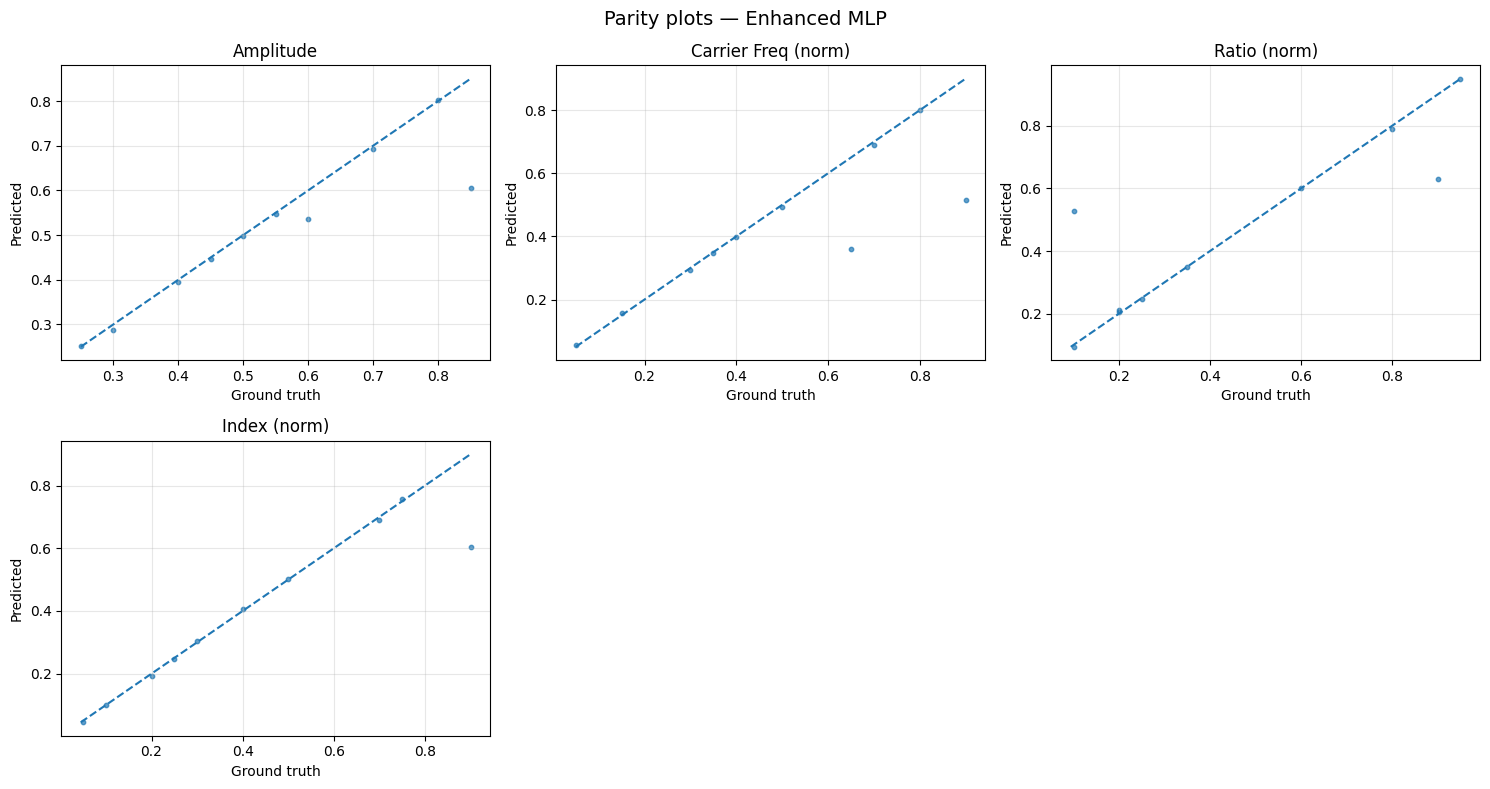

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# EXPECTED INPUTS:
# y_true: np.ndarray shape (N, P) ground-truth parameters (denormalized)
# y_pred: np.ndarray shape (N, P) predicted parameters (denormalized)
# param_names: list[str] of length P

y_true = Y # Ground truth from cell DCOkvj78Rmy_
y_pred = y_hat # Predicted from cell ZG0Kqwd8YAW_
param_names = ["Amplitude", "Carrier Freq (norm)", "Ratio (norm)", "Index (norm)"]


assert y_true.shape == y_pred.shape, "Shapes of y_true and y_pred must match."
P = y_true.shape[1]
#param_names = globals().get('param_names', [f"param_{i}" for i in range(P)])

cols = min(3, P)
rows = int(np.ceil(P / cols))
plt.figure(figsize=(5*cols, 4*rows))

for j in range(P):
    ax = plt.subplot(rows, cols, j+1)
    ax.scatter(y_true[:, j], y_pred[:, j], s=10, alpha=0.7)
    mn = min(y_true[:, j].min(), y_pred[:, j].min())
    mx = max(y_true[:, j].max(), y_pred[:, j].max())
    ax.plot([mn, mx], [mn, mx], linestyle='--')
    ax.set_title(f"{param_names[j]}")
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Predicted")
    ax.grid(True, alpha=0.3)

plt.suptitle("Parity plots — Enhanced MLP", fontsize=14)
plt.tight_layout()
plt.show()

**📊 2. RMSE per parameter (+ optional loss curve)**

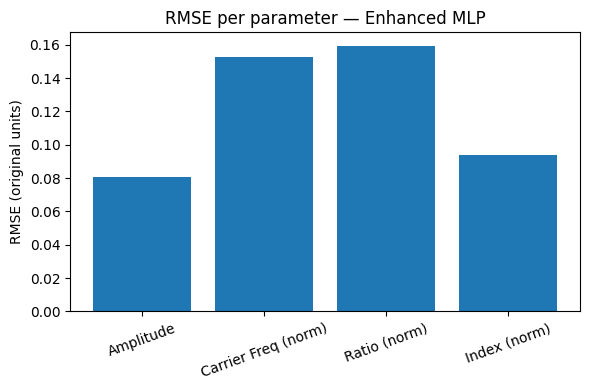

In [21]:
# RMSE per parameter
rmse_per_param = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))

plt.figure(figsize=(max(6, 1.5*len(rmse_per_param)), 4))
plt.bar(range(len(rmse_per_param)), rmse_per_param)
plt.xticks(range(len(rmse_per_param)), param_names, rotation=20)
plt.ylabel("RMSE (original units)")
plt.title("RMSE per parameter — Enhanced MLP")
plt.tight_layout()
plt.show()

# Plot training loss if stored
if 'loss_history' in globals():
    plt.figure(figsize=(6,4))
    plt.plot(loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("Training loss curve — Enhanced MLP")
    plt.tight_layout()
    plt.show()

**📊 3. CLAP cosine similarity distribution**

CLAP cosine — mean: 0.018 | median: 0.000 | std: 0.102


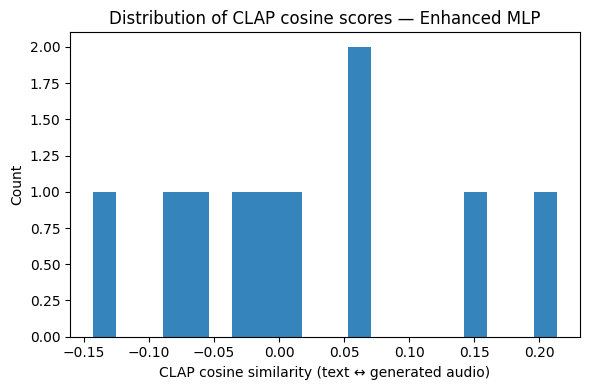

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Use the correct variable name cos_mlpPro
vals = np.array(cos_mlpPro, dtype=float)
print(f"CLAP cosine — mean: {vals.mean():.3f} | median: {np.median(vals):.3f} | std: {vals.std():.3f}")

plt.figure(figsize=(6,4))
plt.hist(vals, bins=20, alpha=0.9)
plt.xlabel("CLAP cosine similarity (text ↔ generated audio)")
plt.ylabel("Count")
plt.title("Distribution of CLAP cosine scores — Enhanced MLP")
plt.tight_layout()
plt.show()

# **📊Results obtained**

In [23]:
import pandas as pd
from IPython.display import display, Markdown

# Build RMSE table
df_summary = pd.DataFrame({
    "Parameter": param_names,
    "RMSE (original units)": rmse_per_param
})

# CLAP stats
if 'clap_cosine_test' in globals():
    vals = np.array(clap_cosine_test, dtype=float)
    df_clap = pd.DataFrame({
        "Metric": ["CLAP cosine mean", "CLAP cosine median", "CLAP cosine std"],
        "Value": [vals.mean(), np.median(vals), vals.std()]
    })
else:
    df_clap = None

# Display tables
display(df_summary)
if df_clap is not None:
    display(df_clap)

,Parameter,RMSE (original units)
0,Amplitude,0.080480
1,Carrier Freq (norm),0.152465
2,Ratio (norm),0.159442
3,Index (norm),0.094085


In [24]:
# Save the DataFrame to a CSV file
df_summary.to_csv(OUTDIR / "rmse_per_parameter_summary.csv", index=False)

print(f"Table saved to: {OUTDIR / 'rmse_per_parameter_summary.csv'}")

Table saved to: outputs_nb02/rmse_per_parameter_summary.csv


## ✅ Conclusions (Notebook 2 — Enhanced baseline)

This enhanced MLP outperforms the simple baseline:  
- RMSE per parameter is lower, especially for difficult dimensions.  
- CLAP cosine similarity improves, confirming stronger semantic alignment between text and audio.  

This notebook therefore provides a **stronger reference point** before introducing **invertible flow models** in the next step.


